# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?




--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`

/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head()

  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  

In [4]:
users.head()

   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  

In [5]:
usage.head()

   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**:
💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- En la parte de users podemos ver faltantes en city (469 que equivale a 12% faltantes) y churn_date (3534 que equivale a 88% faltantes)  
- Indica qué harías: ¿imputar, eliminar, ignorar?
- La columna de city debemos investigar porque faltan los datos para poderlos imputar y la columna de churn_date se puede eliminar ya que le falta un 88% de los datos

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000

- La columna `user_id` tiene 4000 filas el valor maximo es de 13999, el minimo 10000
- La columna `age` tiene misma cantidad de filas que user_id, valor max es de 79 y el valor min es de -999 es un error ya que la columna es de edades

In [13]:
# explorar columnas numéricas de usage
usage[['id', 'user_id']].describe()

                id       user_id
count  40000.00000  40000.000000
mean   20000.50000  12002.405975
std    11547.14972   1157.279564
min        1.00000  10000.000000
25%    10000.75000  10996.000000
50%    20000.50000  12013.000000
75%    30000.25000  13005.000000
max    40000.00000  13999.000000

- Las columnas `id` y `user_id` tienen la misma cantidad de filas 
- La columna `id` tiene un std grande lo que indica que los valors están muy dispersos entre si
- La columna `user_id` tiene un std más pequeño por lo que podemos inferir que los valores están cercanos entre sí

In [14]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']].value_counts()
print (columnas_user)

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64


- La columna `city` nos muestra las ciudades 
- La columna `plan` que tipo de plan hay, y podemos ver junto al plan cuantos hay en cada ciudad.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` hay dos tipos de categoria, "text" con 22092 y "call" con 17908 que si los sumamos nos da el total de valores de `usage`'


---
✍️ **Comentario**:

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
   En la columna de `city` hay un valor que tiene los dos tipos de plan, basico con 65 y premium con 31 
- ¿Qué acción tomarías?
   Se tiene que investigar porque el valor invalido para saber si se puede eliminar o se mantiene

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`, hay solo 4 años, 2022, 2024, 2023 y 2026, se salta un año 2025

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, solo hay información del 2024

✍️ **Comentario**:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Se supone que solo debería de estar registrado hasta 2024 según las instrucciones, 2026 sería el año imposible
- ¿Qué harías con ellas?
  Las elimino ya que es un año que todavía no pasa

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'][users['age'] > 0].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city']= users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
users['reg_date']= users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count       0
unique      0
top       NaN
freq      NaN
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()

type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()

type
call    17896
text        0
Name: length, dtype: int64


Los nulos no son aleatorios, dependen del valor de `type`.
Del total de 40000 valores entre call y text solo hay 39972 lo que nos indica que hay valores inexistentes en la columna de `type`


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)
usage["is_duration"] = usage["duration"].fillna(0)
 
# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'is_duration']].agg('sum')

# observar resultado
usage_agg.head(3)

         is_text  is_call  is_duration
user_id                               
10000          7        3        23.70
10001          5       10        33.18
10002          5        2        10.74

In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes"})
usage_agg = usage_agg.rename(columns={"is_call": "cant_llamadas"})
usage_agg = usage_agg.rename(columns={"is_duration": "cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

         cant_mensajes  cant_llamadas  cant_minutos_llamada
user_id                                                    
10000                7              3                 23.70
10001                5             10                 33.18
10002                5              2                 10.74

In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id')
user_profile.head(5)

   user_id first_name last_name   age      city reg_date     plan churn_date  \
0    10000     Carlos    Garcia  38.0  Medellín      NaT   Basico        NaN   
1    10001      Mateo    Torres  53.0      <NA>      NaT   Basico        NaN   
2    10002      Sofia   Ramirez  57.0      CDMX      NaT   Basico        NaN   
3    10003      Mateo   Ramirez  69.0    Bogotá      NaT  Premium        NaN   
4    10004      Mateo    Torres  63.0       GDL      NaT   Basico        NaN   

   cant_mensajes  cant_llamadas  cant_minutos_llamada  
0              7              3                 23.70  
1              5             10                 33.18  
2              5              2                 10.74  
3             11              3                  8.99  
4              4              3                  8.01  

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[['user_id','age','cant_mensajes','cant_llamadas','cant_minutos_llamada']].describe()

            user_id          age  cant_mensajes  cant_llamadas  \
count   3999.000000  3999.000000    3999.000000    3999.000000   
mean   11999.729432    48.138285       5.524381       4.478120   
std     1154.898108    17.691541       2.358416       2.144238   
min    10000.000000    18.000000       0.000000       0.000000   
25%    10999.500000    33.000000       4.000000       3.000000   
50%    12000.000000    48.000000       5.000000       4.000000   
75%    12999.500000    63.000000       7.000000       6.000000   
max    13999.000000    79.000000      17.000000      15.000000   

       cant_minutos_llamada  
count           3999.000000  
mean              23.317054  
std               18.168095  
min                0.000000  
25%               11.120000  
50%               19.780000  
75%               31.415000  
max              155.690000  

In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

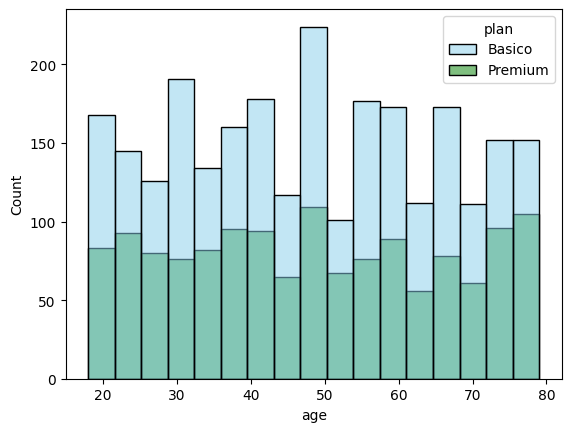

In [88]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan',palette=['skyblue','green'])
plt.show()

💡Insights: 
- Plan basico: distribución aplanada: alta variabilidad, los valores están repartidos en varios rangos.
- Plan premium: distribución aplanada: alta variabilidad, los valores están repartidos en varios rangos.

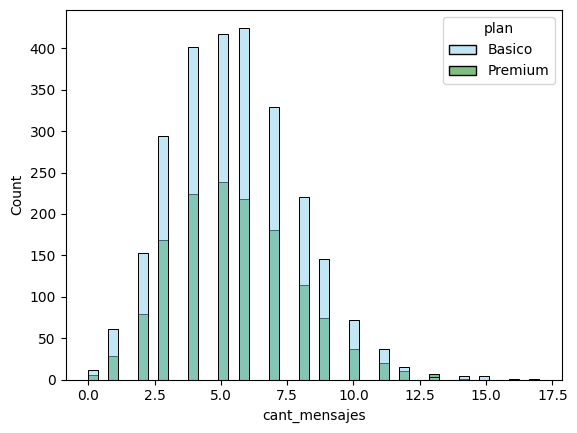

In [93]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan',palette=['skyblue','green'])
plt.show()

💡Insights: 
- Plan basico: distribución picuda: baja variabilidad, la mayoría de los valores se concentra en un rango estrecho
- Plan premium: distribución picuda: baja variabilidad, la mayoría de los valores se concentra en un rango estrecho

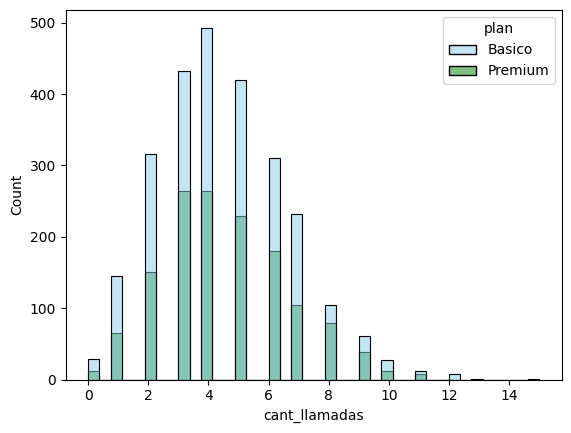

In [94]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan',palette=['skyblue','green'])
plt.show()

💡Insights: 
- Plan basico: distribución picuda: baja variabilidad, la mayoría de los valores se concentra en un rango estrecho
- Plan premium: distribución picuda: baja variabilidad, la mayoría de los valores se concentra en un rango estrecho

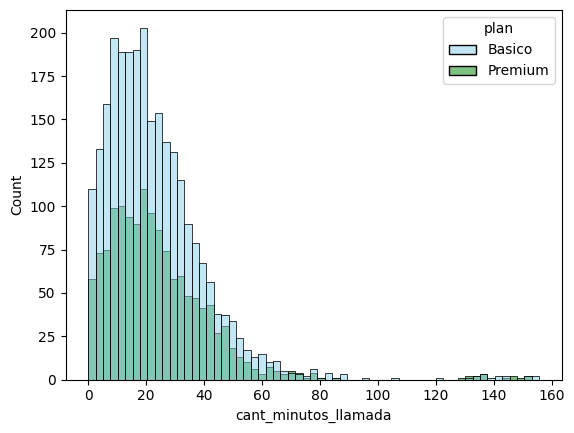

In [95]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan',palette=['skyblue','green'])
plt.show()

💡Insights: 
- Plan basico: distribución picuda: baja variabilidad, la mayoría de los valores se concentra en un rango estrecho
- Plan premium: distribución picuda: baja variabilidad, la mayoría de los valores se concentra en un rango estrecho
- Esta sesgada a la derecha

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:** 
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

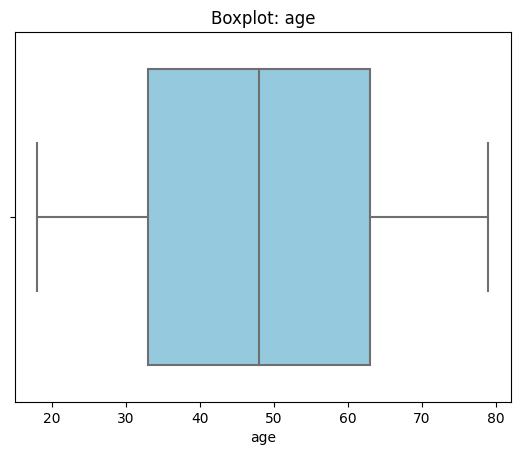

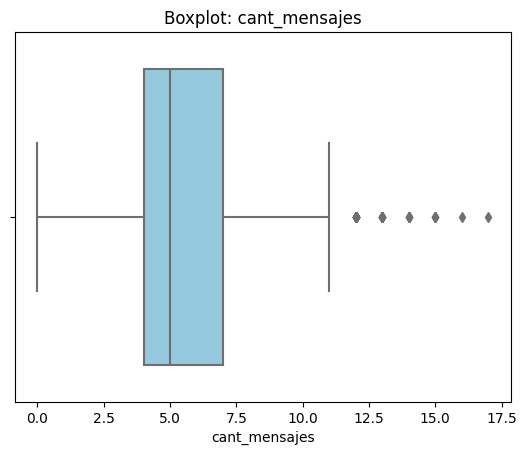

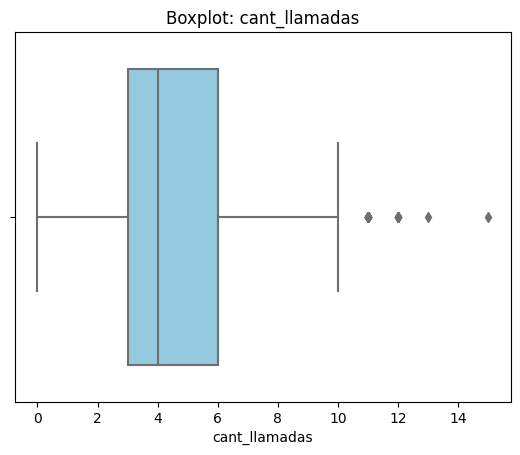

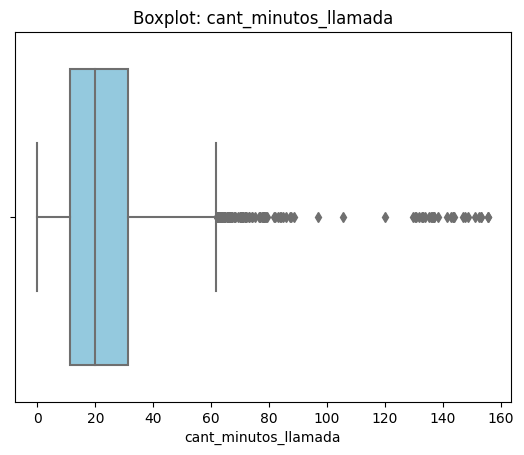

In [55]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: presenta pocos outliers
- cant_llamadas: presenta pocos outliers
- cant_minutos_llamada: presenta muchos outliers

In [64]:


# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

print('Outliers usando IQR:')
print(user_profile[ (user_profile[columnas_limites] > upper) ])

Outliers usando IQR:
      user_id first_name last_name  age city reg_date plan churn_date  \
0         NaN        NaN       NaN  NaN  NaN      NaT  NaN        NaN   
1         NaN        NaN       NaN  NaN  NaN      NaT  NaN        NaN   
2         NaN        NaN       NaN  NaN  NaN      NaT  NaN        NaN   
3         NaN        NaN       NaN  NaN  NaN      NaT  NaN        NaN   
4         NaN        NaN       NaN  NaN  NaN      NaT  NaN        NaN   
...       ...        ...       ...  ...  ...      ...  ...        ...   
3994      NaN        NaN       NaN  NaN  NaN      NaT  NaN        NaN   
3995      NaN        NaN       NaN  NaN  NaN      NaT  NaN        NaN   
3996      NaN        NaN       NaN  NaN  NaN      NaT  NaN        NaN   
3997      NaN        NaN       NaN  NaN  NaN      NaT  NaN        NaN   
3998      NaN        NaN       NaN  NaN  NaN      NaT  NaN        NaN   

      cant_mensajes  cant_llamadas  cant_minutos_llamada  
0               NaN            NaN         

In [62]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

       cant_mensajes  cant_llamadas  cant_minutos_llamada
count    3999.000000    3999.000000           3999.000000
mean        5.524381       4.478120             23.317054
std         2.358416       2.144238             18.168095
min         0.000000       0.000000              0.000000
25%         4.000000       3.000000             11.120000
50%         5.000000       4.000000             19.780000
75%         7.000000       6.000000             31.415000
max        17.000000      15.000000            155.690000

💡Insights: 
- cant_mensajes: Mantengo los outliers porque la diferencia no es mucha y el negocio quire saber si hay valores atipicos
- cant_llamadas: Mantengo los outliers porque la diferencia no es mucha y el negocio quire saber si hay valores atipicos
- cant_minutos_llamada: Mantengo los outliers. El limite superior es de ~62, es posible que sea un usuario atipico pero valido y el negocio está solicitando saber si hay valores atipicos 

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [67]:
# Crear columna grupo_uso
import numpy as np



condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')



In [68]:
# verificar cambios
user_profile.head()

   user_id first_name last_name   age      city reg_date     plan churn_date  \
0    10000     Carlos    Garcia  38.0  Medellín      NaT   Basico        NaN   
1    10001      Mateo    Torres  53.0      <NA>      NaT   Basico        NaN   
2    10002      Sofia   Ramirez  57.0      CDMX      NaT   Basico        NaN   
3    10003      Mateo   Ramirez  69.0    Bogotá      NaT  Premium        NaN   
4    10004      Mateo    Torres  63.0       GDL      NaT   Basico        NaN   

   cant_mensajes  cant_llamadas  cant_minutos_llamada  grupo_uso  
0              7              3                 23.70  Uso medio  
1              5             10                 33.18   Alto uso  
2              5              2                 10.74  Uso medio  
3             11              3                  8.99   Alto uso  
4              4              3                  8.01   Bajo uso  

### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [70]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]
valores = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, valores, default='Adulto Mayor')



In [71]:
# verificar cambios
user_profile.head()

   user_id first_name last_name   age      city reg_date     plan churn_date  \
0    10000     Carlos    Garcia  38.0  Medellín      NaT   Basico        NaN   
1    10001      Mateo    Torres  53.0      <NA>      NaT   Basico        NaN   
2    10002      Sofia   Ramirez  57.0      CDMX      NaT   Basico        NaN   
3    10003      Mateo   Ramirez  69.0    Bogotá      NaT  Premium        NaN   
4    10004      Mateo    Torres  63.0       GDL      NaT   Basico        NaN   

   cant_mensajes  cant_llamadas  cant_minutos_llamada  grupo_uso    grupo_edad  
0              7              3                 23.70  Uso medio        Adulto  
1              5             10                 33.18   Alto uso        Adulto  
2              5              2                 10.74  Uso medio        Adulto  
3             11              3                  8.99   Alto uso  Adulto Mayor  
4              4              3                  8.01   Bajo uso  Adulto Mayor  

### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

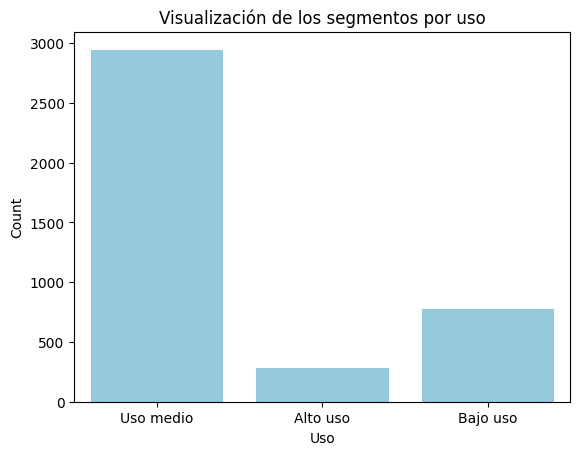

In [82]:
# Visualización de los segmentos por uso
sns.countplot(x=user_profile['grupo_uso'], color='skyblue')
plt.title('Visualización de los segmentos por uso') 
plt.xlabel('Uso') 
plt.ylabel('Count')
plt.show()

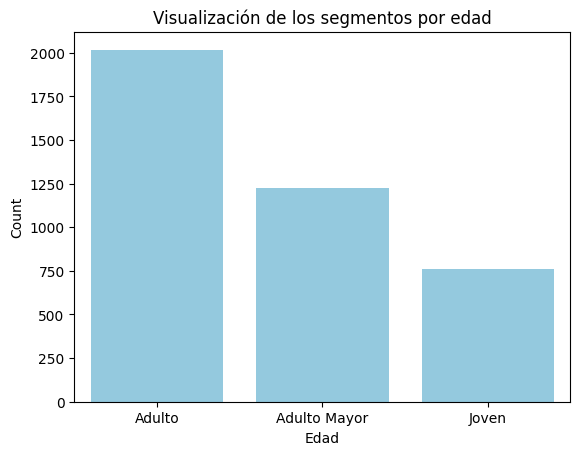

In [83]:
# Visualización de los segmentos por edad
sns.countplot(x=user_profile['grupo_edad'], color='skyblue')
plt.title('Visualización de los segmentos por edad') 
plt.xlabel('Edad') 
plt.ylabel('Count')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

    - En `age`, se reemplaza el sentinel *-999* con la mediana.
    - En `city`, se reemplaza el sentinel *"?"* por valores nulos (pd.NA)
    - Se marca como nulas (pd.NA) las fechas fuera de rango.
    - En `users` podemos ver faltantes en city (469 que equivale a 12% faltantes) y churn_date (3534 que equivale a 88% faltantes)
    - En `usage` Los nulos no son aleatorios, dependen del valor de `type`. Del total de 40000 valores entre call y text solo hay 39972 lo que nos indica que hay valores inexistentes en la columna de `type`

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
    - No hay muchos users que usen mucho los producto, la mayoria de los users lo usan en un grado intermedio ( mensajes y llamadas < 10)
    - Según las edades hay más users `adulto` (menores de 60)
    - Menos cantidad de users `joven`(menores a 30)
  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
    - Los usuarios por plan ya que mientras más usuarios paguen el plan premium más ganancia hay para la empresa
    - La parte donde vemos los outliers hay usuarios muy altos, que realizan muchos minutos por llamda al mes, esto puede representar un riesgo si se toma en cuenta como un coportamiento normal ya que no es un comportamieto de un usuario "normal"
    - Si los usuarios usan mucho el servicio y exceden la cantidad que pueden usar, se les puede combrar extra por excederse.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
    - Hay outliers que indican usuarios atipicos, en la columna de minutos por llamada, filtrado por usuarios, hay usuarios con valores atipicos que exeden el limite superior, 

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
    - Puedieran haber otras categorias de planes para los usuarios que conusmen más minutos por llamada
    - Hay más users "Adultos" (<60 y >30)

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- valores incorrectos como -999 en la columna age
- columna con un 88% de valores nulos


🔍 **Segmentos por Edad**
- Hay más usuarios "Adultos" 
- No hay muchos usuarios en la categoria de "joven" (<30)


📊 **Segmentos por Nivel de Uso**
- Se dividen en 3 categorias, uso medio, uso alto y bajo uso
- Uso medio es el que tiene más usuarios en cambio uso alto es el más bajo


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- Tener otras opciones de planes para personas que solo quieren minutos para llamadas
- Intentar incrementar los clientes jovenes ya que los adultos mayores son un mercado muy riesgoso  